# Gamma Scalping Strategy Analysis
## Interactive visualization of Greeks, hedging, and P&L dynamics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
sys.path.append(str(Path().absolute().parent))

from data.data_loader import DataLoader
from backtest.backtest_engine import BacktestEngine, BacktestConfig, StrategyConfig
from simulation.portfolio_dynamics import PortfolioDynamics
from models.options_pricing import delta, gamma, theta, vega, bs_price, implied_volatility

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

## 1. Load and Prepare Data

In [ ]:
# Load data
# Fix path for notebook location
import os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')  # Go up to project root
    print(f"Changed directory to: {os.getcwd()}")

loader = DataLoader()

# Load April 2020 data
start_date = pd.Timestamp('2020-04-01')
end_date = pd.Timestamp('2020-04-10')

spot_data, options_data = loader.create_synchronized_dataset(
    spot_symbol='BTCUSDT',
    underlying='BTC',
    start_date=start_date,
    end_date=end_date
)

print(f"Loaded {len(spot_data)} spot prices")
print(f"Loaded {len(options_data)} option data points")
print(f"Date range: {spot_data['timestamp'].min()} to {spot_data['timestamp'].max()}")
print(f"\nSpot price range: ${spot_data['close'].min():.2f} - ${spot_data['close'].max():.2f}")

## 2. Run Gamma Scalping Backtest with Continuous Hedging

In [24]:
# Configure backtest with continuous hedging (threshold = 0)
backtest_config = BacktestConfig(
    initial_capital=100000,
    commission_rate=0.0005,
    slippage_bps=10,
    risk_free_rate=0.01
)

# Strategy with continuous rehedging
continuous_hedge = StrategyConfig(
    name="Continuous Hedging",
    hedge_threshold=0.001,  # Rehedge at every timestep (almost 0)
    hedge_method='delta_band',
    option_selection='atm',
    position_size=1.0
)

# Strategy with threshold hedging
threshold_hedge = StrategyConfig(
    name="Threshold Hedging (10%)",
    hedge_threshold=0.10,  # Rehedge when delta > 10%
    hedge_method='delta_band',
    option_selection='atm',
    position_size=1.0
)

# Run backtests
engine = BacktestEngine(backtest_config)

print("Running continuous hedging backtest...")
continuous_result = engine.run_backtest(spot_data, options_data, continuous_hedge)

print("Running threshold hedging backtest...")
threshold_result = engine.run_backtest(spot_data, options_data, threshold_hedge)

print("\nResults:")
print(f"Continuous Hedging - Return: {continuous_result['total_return']:.2%}, Sharpe: {continuous_result['sharpe_ratio']:.2f}")
print(f"Threshold Hedging - Return: {threshold_result['total_return']:.2%}, Sharpe: {threshold_result['sharpe_ratio']:.2f}")

Running continuous hedging backtest...
Running threshold hedging backtest...

Results:
Continuous Hedging - Return: 0.02%, Sharpe: 0.29
Threshold Hedging - Return: 0.05%, Sharpe: 0.61


## 3. Greeks Evolution Over Time

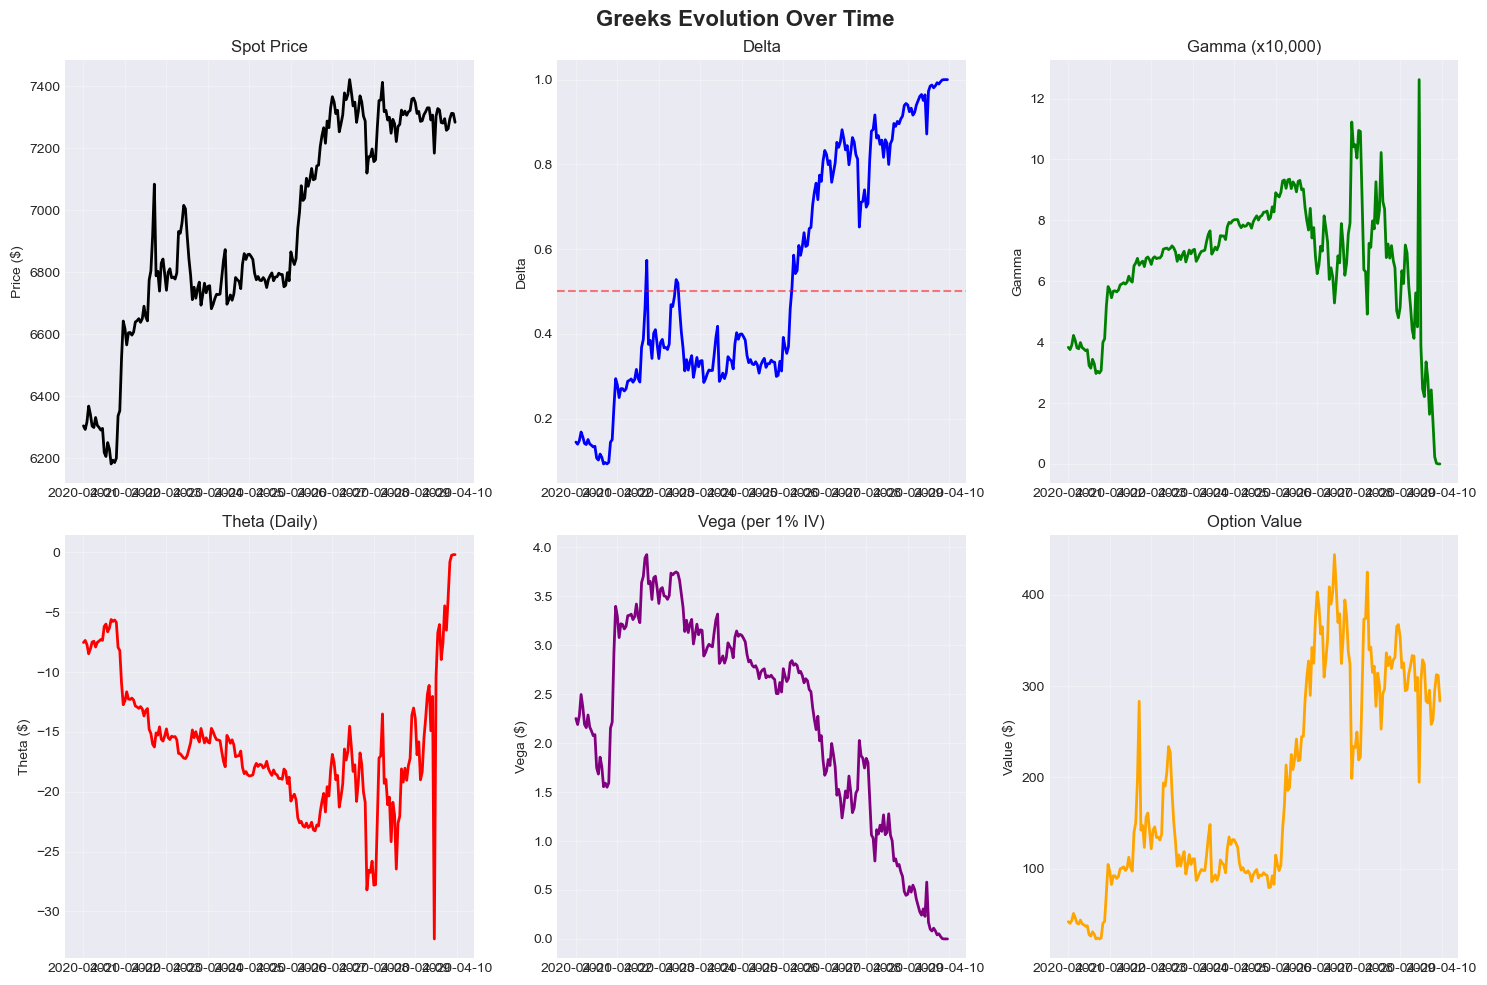

Greeks Summary:
Delta range: 0.093 to 1.000
Max Gamma: 0.001262
Avg daily Theta: $-15.98


In [25]:
# Create a detailed Greeks tracking simulation
def track_greeks_evolution(spot_data, strike=7000, expiry_date='2020-04-10', iv=0.6):
    """Track how Greeks evolve over time"""
    
    greeks_history = []
    expiry = pd.Timestamp(expiry_date)
    
    for idx, row in spot_data.iterrows():
        spot = row['close']
        current_time = row['timestamp']
        
        # Calculate time to expiry
        tte = max(0, (expiry - current_time).total_seconds() / (365 * 24 * 3600))
        
        if tte > 0:
            # Calculate Greeks
            call_delta = delta(spot, strike, tte, 0.01, iv, 'call')
            call_gamma = gamma(spot, strike, tte, 0.01, iv)
            call_theta = theta(spot, strike, tte, 0.01, iv, 'call')
            call_vega = vega(spot, strike, tte, 0.01, iv)
            
            # Calculate option value
            call_price = bs_price(spot, strike, tte, 0.01, iv, 'call')
            
            greeks_history.append({
                'timestamp': current_time,
                'spot': spot,
                'tte_days': tte * 365,
                'delta': call_delta,
                'gamma': call_gamma,
                'theta': call_theta / 365,  # Daily theta
                'vega': call_vega / 100,  # Vega per 1%
                'option_value': call_price,
                'moneyness': spot / strike
            })
    
    return pd.DataFrame(greeks_history)

# Track Greeks
greeks_df = track_greeks_evolution(spot_data)  # First 100 hours

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Greeks Evolution Over Time', fontsize=16, fontweight='bold')

# Spot price
ax = axes[0, 0]
ax.plot(greeks_df['timestamp'], greeks_df['spot'], color='black', linewidth=2)
ax.set_title('Spot Price')
ax.set_ylabel('Price ($)')
ax.grid(True, alpha=0.3)

# Delta
ax = axes[0, 1]
ax.plot(greeks_df['timestamp'], greeks_df['delta'], color='blue', linewidth=2)
ax.set_title('Delta')
ax.set_ylabel('Delta')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Gamma
ax = axes[0, 2]
ax.plot(greeks_df['timestamp'], greeks_df['gamma'] * 10000, color='green', linewidth=2)
ax.set_title('Gamma (x10,000)')
ax.set_ylabel('Gamma')
ax.grid(True, alpha=0.3)

# Theta
ax = axes[1, 0]
ax.plot(greeks_df['timestamp'], greeks_df['theta'], color='red', linewidth=2)
ax.set_title('Theta (Daily)')
ax.set_ylabel('Theta ($)')
ax.grid(True, alpha=0.3)

# Vega
ax = axes[1, 1]
ax.plot(greeks_df['timestamp'], greeks_df['vega'], color='purple', linewidth=2)
ax.set_title('Vega (per 1% IV)')
ax.set_ylabel('Vega ($)')
ax.grid(True, alpha=0.3)

# Option Value
ax = axes[1, 2]
ax.plot(greeks_df['timestamp'], greeks_df['option_value'], color='orange', linewidth=2)
ax.set_title('Option Value')
ax.set_ylabel('Value ($)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Greeks Summary:")
print(f"Delta range: {greeks_df['delta'].min():.3f} to {greeks_df['delta'].max():.3f}")
print(f"Max Gamma: {greeks_df['gamma'].max():.6f}")
print(f"Avg daily Theta: ${greeks_df['theta'].mean():.2f}")

## 4. Hedging Activity Visualization

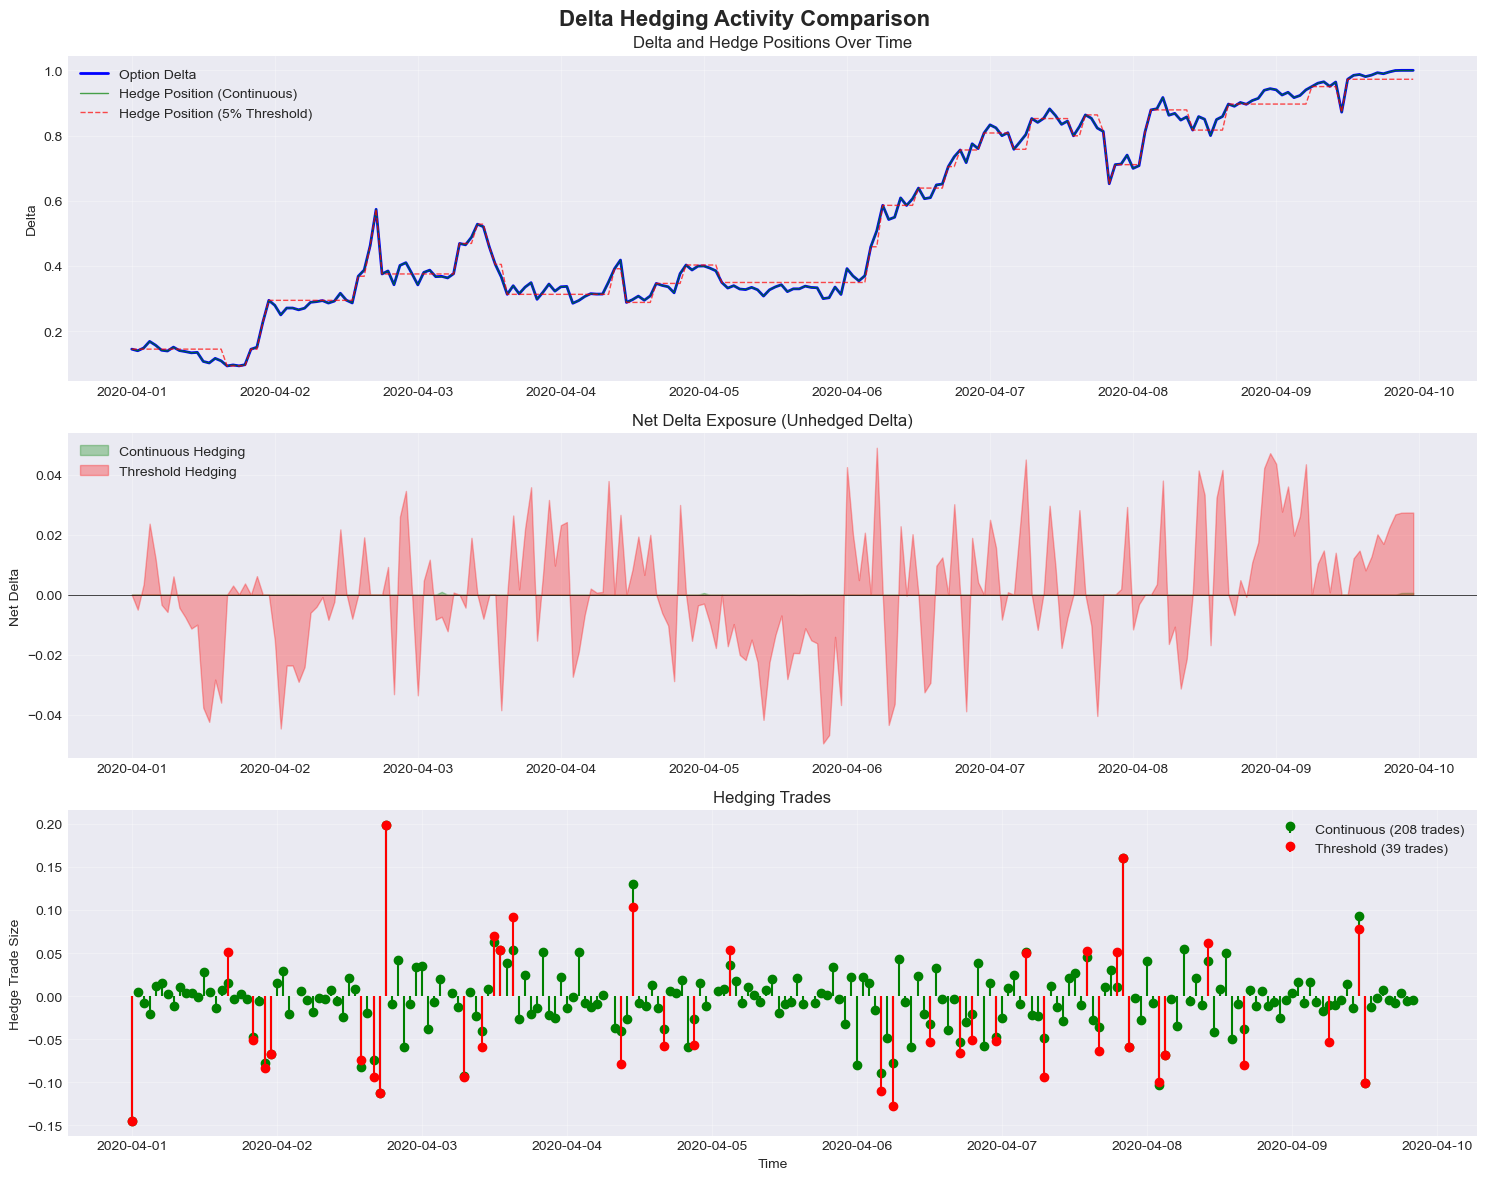

Hedging Statistics:
Continuous: 208 trades, avg size: 0.0264
Threshold: 39 trades, avg size: 0.0801

Max net delta exposure:
  Continuous: 0.0010
  Threshold: 0.0496


In [31]:
# Simulate hedging activity
def simulate_hedging(spot_data, threshold=0.1, strike=7000, iv=0.6):
    """Simulate delta hedging with given threshold"""
    
    hedge_history = []
    current_hedge = 0
    target_delta = 0
    expiry = pd.Timestamp('2020-04-10')
    
    for idx, row in spot_data.iterrows():
        spot = row['close']
        current_time = row['timestamp']
        
        # Calculate current delta
        tte = max(0, (expiry - current_time).total_seconds() / (365 * 24 * 3600))
        if tte > 0:
            current_delta = delta(spot, strike, tte, 0.01, iv, 'call')
            
            # Check if rehedge needed
            delta_diff = current_delta - current_hedge
            needs_hedge = abs(delta_diff) > threshold
            
            if needs_hedge:
                hedge_trade = -delta_diff  # Hedge the difference
                current_hedge = current_delta
            else:
                hedge_trade = 0
            
            hedge_history.append({
                'timestamp': current_time,
                'spot': spot,
                'option_delta': current_delta,
                'hedge_position': -current_hedge,  # Short position to hedge
                'net_delta': current_delta - current_hedge,
                'hedge_trade': hedge_trade,
                'needs_hedge': needs_hedge
            })
    
    return pd.DataFrame(hedge_history)

# Simulate with different thresholds
hedge_continuous = simulate_hedging(spot_data, threshold=0.001)  # Almost continuous
hedge_threshold = simulate_hedging(spot_data, threshold=0.05)   # 5% threshold

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Delta Hedging Activity Comparison', fontsize=16, fontweight='bold')

# Plot 1: Delta Evolution
ax = axes[0]
ax.plot(hedge_continuous['timestamp'], hedge_continuous['option_delta'], 
        label='Option Delta', color='blue', linewidth=2)
ax.plot(hedge_continuous['timestamp'], -hedge_continuous['hedge_position'], 
        label='Hedge Position (Continuous)', color='green', linewidth=1, alpha=0.7)
ax.plot(hedge_threshold['timestamp'], -hedge_threshold['hedge_position'], 
        label='Hedge Position (5% Threshold)', color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.set_title('Delta and Hedge Positions Over Time')
ax.set_ylabel('Delta')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Net Delta Exposure
ax = axes[1]
ax.fill_between(hedge_continuous['timestamp'], 0, hedge_continuous['net_delta'], 
                color='green', alpha=0.3, label='Continuous Hedging')
ax.fill_between(hedge_threshold['timestamp'], 0, hedge_threshold['net_delta'], 
                color='red', alpha=0.3, label='Threshold Hedging')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Net Delta Exposure (Unhedged Delta)')
ax.set_ylabel('Net Delta')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Hedge Trades
ax = axes[2]
# Continuous hedging trades
continuous_trades = hedge_continuous[hedge_continuous['hedge_trade'] != 0]
ax.stem(continuous_trades['timestamp'], continuous_trades['hedge_trade'], 
        linefmt='g-', markerfmt='go', basefmt=' ', label=f'Continuous ({len(continuous_trades)} trades)')

# Threshold hedging trades
threshold_trades = hedge_threshold[hedge_threshold['hedge_trade'] != 0]
ax.stem(threshold_trades['timestamp'], threshold_trades['hedge_trade'], 
        linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Threshold ({len(threshold_trades)} trades)')

ax.set_title('Hedging Trades')
ax.set_ylabel('Hedge Trade Size')
ax.set_xlabel('Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Hedging Statistics:")
print(f"Continuous: {len(continuous_trades)} trades, avg size: {abs(continuous_trades['hedge_trade']).mean():.4f}")
print(f"Threshold: {len(threshold_trades)} trades, avg size: {abs(threshold_trades['hedge_trade']).mean():.4f}")
print(f"")
print(f"Max net delta exposure:")
print(f"  Continuous: {abs(hedge_continuous['net_delta']).max():.4f}")
print(f"  Threshold: {abs(hedge_threshold['net_delta']).max():.4f}")

## 5. P&L Attribution and Decomposition

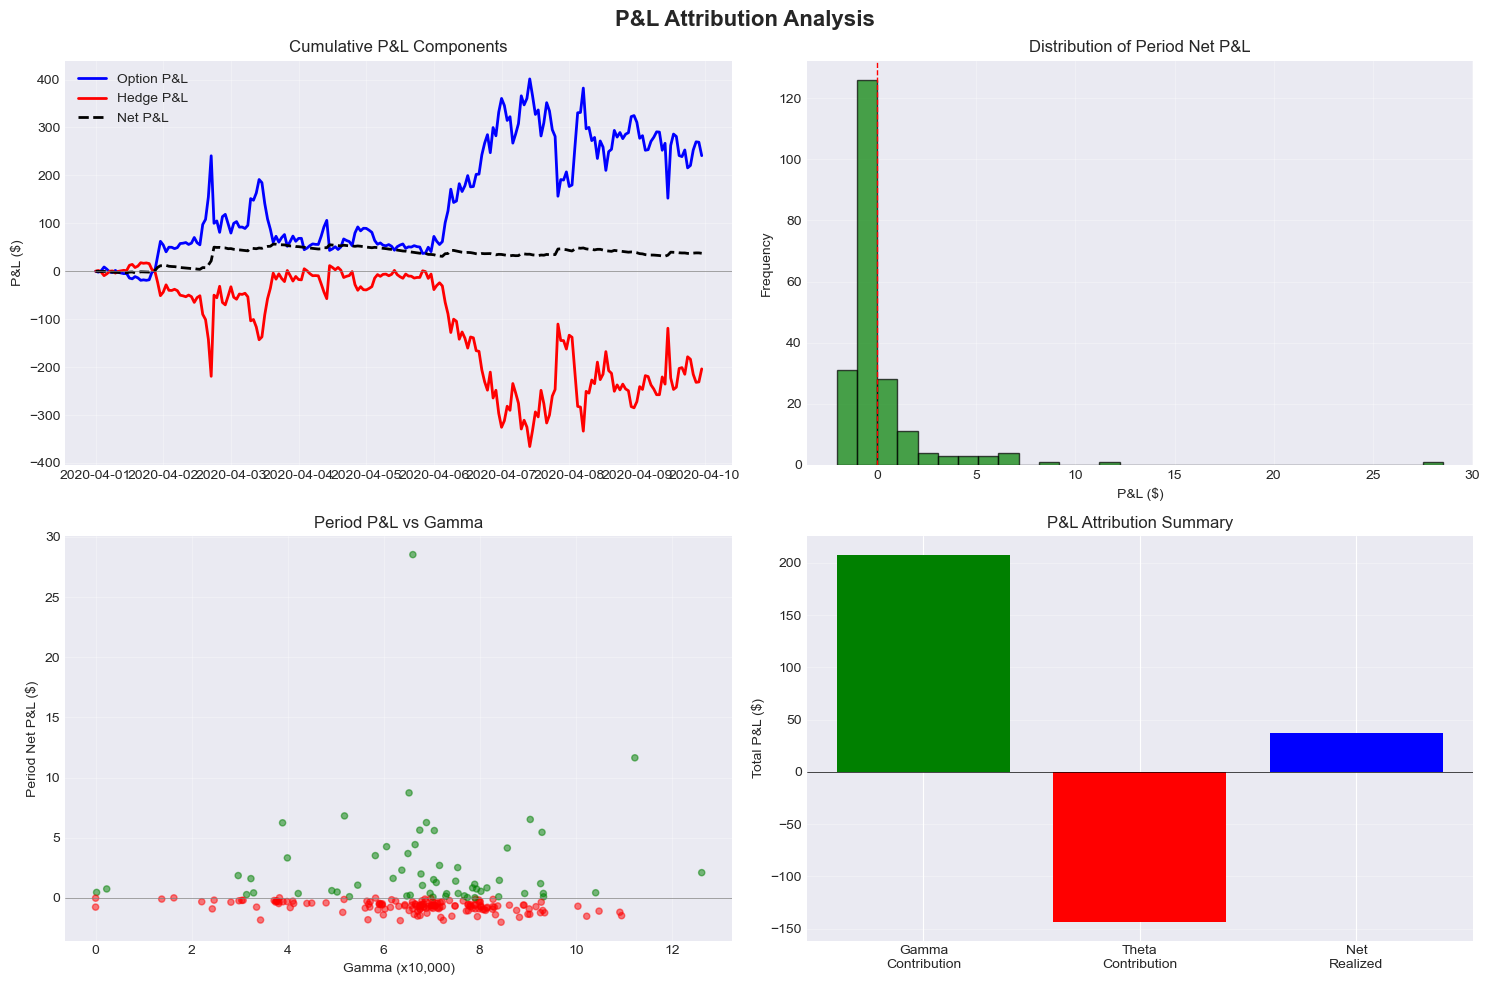

P&L Summary:
Total Option P&L: $241.23
Total Hedge P&L: $-203.73
Total Net P&L: $37.50

Win Rate: 27.3%
Avg Win: $2.55
Avg Loss: $-0.73

Estimated Gamma P&L: $207.97
Estimated Theta Cost: $-143.79


In [33]:
# P&L simulation with attribution
def simulate_pnl_attribution(spot_data, hedge_threshold=0.05, strike=7000, iv=0.6):
    """Simulate P&L with detailed attribution"""
    
    pnl_history = []
    expiry = pd.Timestamp('2020-04-10')
    
    # Initial setup
    initial_spot = spot_data.iloc[0]['close']
    initial_tte = (expiry - spot_data.iloc[0]['timestamp']).total_seconds() / (365 * 24 * 3600)
    option_price = bs_price(initial_spot, strike, initial_tte, 0.01, iv, 'call')
    hedge_position = -delta(initial_spot, strike, initial_tte, 0.01, iv, 'call')
    
    prev_spot = initial_spot
    prev_option_value = option_price
    cumulative_option_pnl = 0
    cumulative_hedge_pnl = 0
    
    for idx, row in spot_data.iterrows():
        spot = row['close']
        current_time = row['timestamp']
        tte = max(0, (expiry - current_time).total_seconds() / (365 * 24 * 3600))
        
        if tte > 0:
            # Current option value
            current_option_value = bs_price(spot, strike, tte, 0.01, iv, 'call')
            
            # P&L components
            option_pnl = current_option_value - prev_option_value
            hedge_pnl = hedge_position * (spot - prev_spot)
            net_pnl = option_pnl + hedge_pnl
            
            cumulative_option_pnl += option_pnl
            cumulative_hedge_pnl += hedge_pnl
            
            # Calculate Greeks for attribution
            current_delta = delta(spot, strike, tte, 0.01, iv, 'call')
            current_gamma = gamma(spot, strike, tte, 0.01, iv)
            current_theta = theta(spot, strike, tte, 0.01, iv, 'call') / 365
            
            # Check if rehedge
            if abs(current_delta + hedge_position) > hedge_threshold:
                hedge_position = -current_delta
            
            pnl_history.append({
                'timestamp': current_time,
                'spot': spot,
                'option_value': current_option_value,
                'period_option_pnl': option_pnl,
                'period_hedge_pnl': hedge_pnl,
                'period_net_pnl': net_pnl,
                'cumulative_option_pnl': cumulative_option_pnl,
                'cumulative_hedge_pnl': cumulative_hedge_pnl,
                'cumulative_net_pnl': cumulative_option_pnl + cumulative_hedge_pnl,
                'delta': current_delta,
                'gamma': current_gamma,
                'theta': current_theta
            })
            
            prev_spot = spot
            prev_option_value = current_option_value
    
    return pd.DataFrame(pnl_history)

# Simulate P&L
pnl_df = simulate_pnl_attribution(spot_data)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('P&L Attribution Analysis', fontsize=16, fontweight='bold')

# Cumulative P&L Components
ax = axes[0, 0]
ax.plot(pnl_df['timestamp'], pnl_df['cumulative_option_pnl'], 
        label='Option P&L', color='blue', linewidth=2)
ax.plot(pnl_df['timestamp'], pnl_df['cumulative_hedge_pnl'], 
        label='Hedge P&L', color='red', linewidth=2)
ax.plot(pnl_df['timestamp'], pnl_df['cumulative_net_pnl'], 
        label='Net P&L', color='black', linewidth=2, linestyle='--')
ax.set_title('Cumulative P&L Components')
ax.set_ylabel('P&L ($)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Period P&L Distribution
ax = axes[0, 1]
ax.hist(pnl_df['period_net_pnl'], bins=30, alpha=0.7, color='green', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_title('Distribution of Period Net P&L')
ax.set_xlabel('P&L ($)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# P&L vs Gamma
ax = axes[1, 0]
colors = pnl_df['period_net_pnl'].apply(lambda x: 'green' if x > 0 else 'red')
ax.scatter(pnl_df['gamma'] * 10000, pnl_df['period_net_pnl'], 
          c=colors, alpha=0.5, s=20)
ax.set_title('Period P&L vs Gamma')
ax.set_xlabel('Gamma (x10,000)')
ax.set_ylabel('Period Net P&L ($)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Greeks Contribution
ax = axes[1, 1]
# Estimate Greeks contribution
spot_returns = pnl_df['spot'].pct_change()
gamma_pnl = 0.5 * pnl_df['gamma'] * (pnl_df['spot'].diff() ** 2)
theta_pnl = pnl_df['theta'] * (1/24)  # Hourly theta

ax.bar(['Gamma\nContribution', 'Theta\nContribution', 'Net\nRealized'], 
       [gamma_pnl.sum(), theta_pnl.sum(), pnl_df['cumulative_net_pnl'].iloc[-1]],
       color=['green', 'red', 'blue'])
ax.set_title('P&L Attribution Summary')
ax.set_ylabel('Total P&L ($)')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Statistics
print(f"P&L Summary:")
print(f"Total Option P&L: ${pnl_df['cumulative_option_pnl'].iloc[-1]:.2f}")
print(f"Total Hedge P&L: ${pnl_df['cumulative_hedge_pnl'].iloc[-1]:.2f}")
print(f"Total Net P&L: ${pnl_df['cumulative_net_pnl'].iloc[-1]:.2f}")
print(f"")
print(f"Win Rate: {(pnl_df['period_net_pnl'] > 0).mean():.1%}")
print(f"Avg Win: ${pnl_df[pnl_df['period_net_pnl'] > 0]['period_net_pnl'].mean():.2f}")
print(f"Avg Loss: ${pnl_df[pnl_df['period_net_pnl'] < 0]['period_net_pnl'].mean():.2f}")
print(f"")
print(f"Estimated Gamma P&L: ${gamma_pnl.sum():.2f}")
print(f"Estimated Theta Cost: ${theta_pnl.sum():.2f}")

## 6. Volatility Analysis

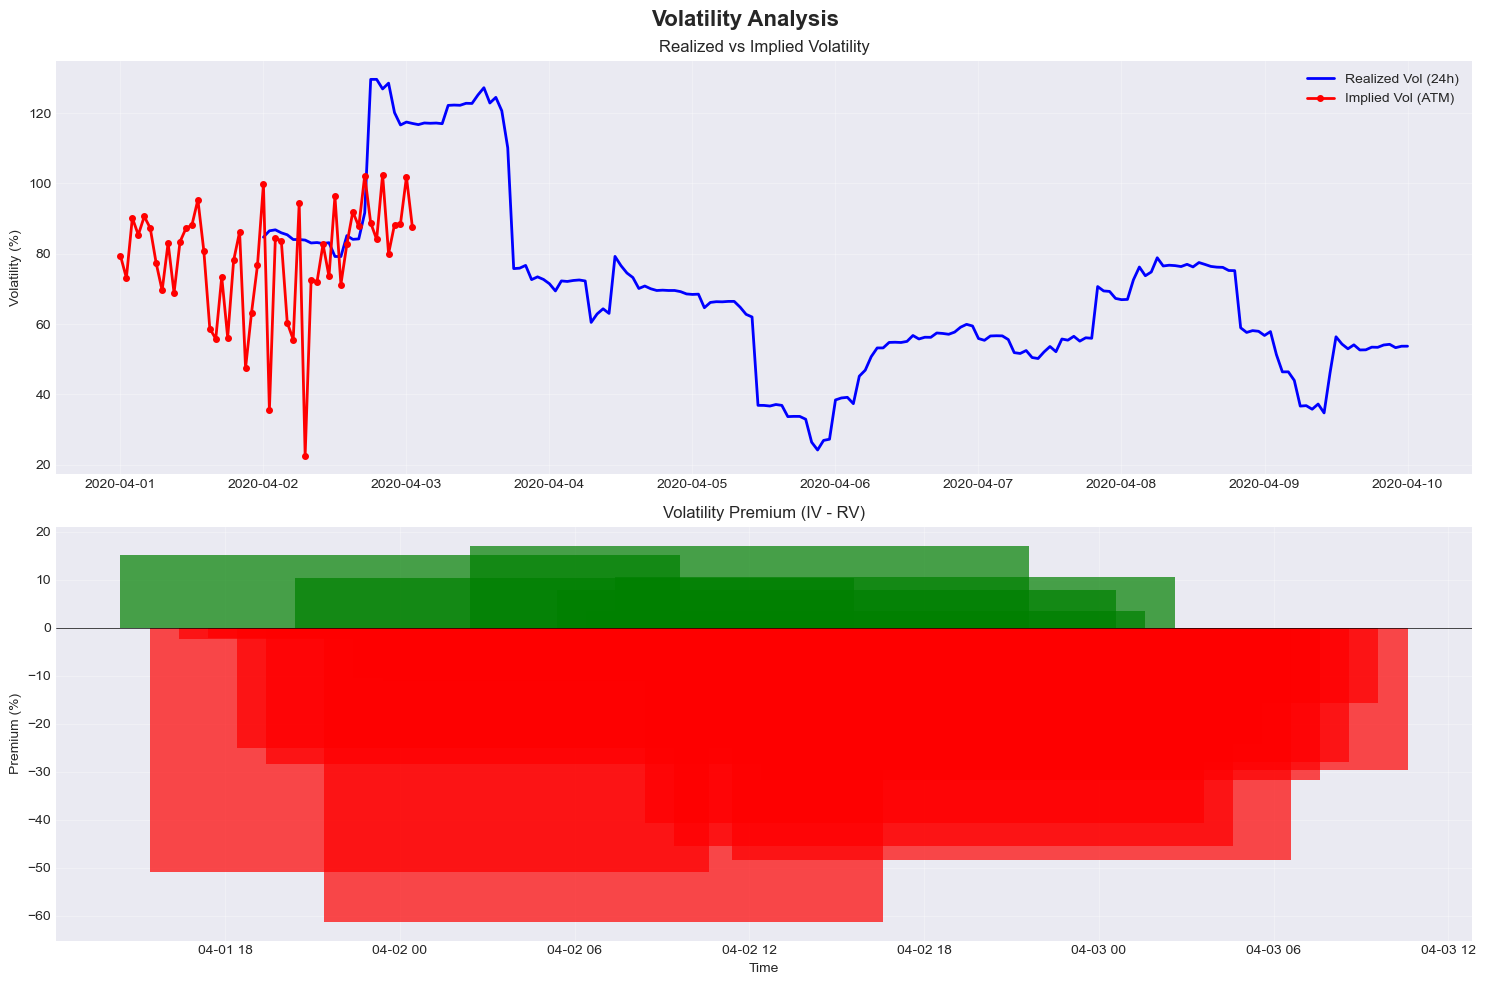

Volatility Statistics:
Average Realized Vol: 68.9%
Average Implied Vol: 78.5%
Average Vol Premium: 9.7%


In [28]:
# Analyze realized vs implied volatility
def analyze_volatility(spot_data, options_data):
    """Compare realized and implied volatility"""
    
    # Calculate realized volatility
    returns = np.log(spot_data['close'] / spot_data['close'].shift(1))
    
    # Rolling realized vol (hourly returns annualized)
    window = 24  # 24 hours = 1 day
    realized_vol = returns.rolling(window=window).std() * np.sqrt(24 * 365)
    
    # Get ATM options for IV
    atm_options = []
    for timestamp in spot_data['timestamp'].unique()[:50]:
        spot = spot_data[spot_data['timestamp'] == timestamp]['close'].iloc[0]
        
        # Find ATM options at this timestamp
        opts_at_time = options_data[options_data['timestamp'] == timestamp]
        if not opts_at_time.empty:
            opts_at_time = opts_at_time.copy()
            opts_at_time['moneyness'] = abs(opts_at_time['strike'] - spot) / spot
            atm = opts_at_time.nsmallest(1, 'moneyness')
            
            if not atm.empty:
                opt = atm.iloc[0]
                # Calculate IV
                tte = (opt['expiry'] - timestamp).total_seconds() / (365 * 24 * 3600)
                if tte > 0:
                    option_price_usd = opt['close'] * spot  # Convert BTC to USD
                    iv = implied_volatility(option_price_usd, spot, opt['strike'], 
                                           tte, 0.01, opt['option_type'])
                    if not np.isnan(iv):
                        atm_options.append({
                            'timestamp': timestamp,
                            'spot': spot,
                            'strike': opt['strike'],
                            'iv': iv
                        })
    
    iv_df = pd.DataFrame(atm_options)
    
    return realized_vol, iv_df

# Analyze volatility
realized_vol, iv_df = analyze_volatility(spot_data, options_data)

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Volatility Analysis', fontsize=16, fontweight='bold')

# Volatility comparison
ax = axes[0]
ax.plot(spot_data['timestamp'], realized_vol * 100, 
        label='Realized Vol (24h)', color='blue', linewidth=2)
if not iv_df.empty:
    ax.plot(iv_df['timestamp'], iv_df['iv'] * 100, 
            label='Implied Vol (ATM)', color='red', linewidth=2, marker='o', markersize=4)
ax.set_title('Realized vs Implied Volatility')
ax.set_ylabel('Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Volatility premium
ax = axes[1]
if not iv_df.empty:
    # Align data
    merged = pd.merge_asof(
        iv_df.sort_values('timestamp'),
        spot_data[['timestamp', 'close']].sort_values('timestamp'),
        on='timestamp'
    )
    merged_rv = pd.merge_asof(
        merged,
        pd.DataFrame({'timestamp': spot_data['timestamp'], 'rv': realized_vol}).sort_values('timestamp'),
        on='timestamp'
    )
    
    if 'rv' in merged_rv.columns:
        vol_premium = (merged_rv['iv'] - merged_rv['rv']) * 100
        ax.bar(merged_rv['timestamp'], vol_premium, 
               color=['green' if x > 0 else 'red' for x in vol_premium],
               alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.set_title('Volatility Premium (IV - RV)')
        ax.set_ylabel('Premium (%)')
        ax.set_xlabel('Time')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if not iv_df.empty:
    print(f"Volatility Statistics:")
    print(f"Average Realized Vol: {realized_vol.dropna().mean() * 100:.1f}%")
    print(f"Average Implied Vol: {iv_df['iv'].mean() * 100:.1f}%")
    print(f"Average Vol Premium: {(iv_df['iv'].mean() - realized_vol.dropna().mean()) * 100:.1f}%")

## 7. Strategy Comparison Dashboard

In [29]:
# Load saved results for comparison
results_df = pd.read_csv('../backtest/results/gamma_scalping_results.csv')

# Create comprehensive dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Gamma Scalping Strategy Comparison Dashboard', fontsize=16, fontweight='bold')

# 1. Returns comparison
ax1 = fig.add_subplot(gs[0, 0])
colors = ['green' if x > 0 else 'red' for x in results_df['total_return']]
ax1.barh(range(len(results_df)), results_df['total_return'] * 100, color=colors)
ax1.set_yticks(range(len(results_df)))
ax1.set_yticklabels([s[:15] for s in results_df['strategy']], fontsize=8)
ax1.set_xlabel('Return (%)')
ax1.set_title('Strategy Returns')
ax1.grid(True, alpha=0.3, axis='x')

# 2. Sharpe Ratio
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(results_df['total_return'] * 100, results_df['sharpe_ratio'], 
           s=100, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for i, txt in enumerate(results_df['strategy']):
    ax2.annotate(txt[:10], (results_df['total_return'].iloc[i] * 100, 
                            results_df['sharpe_ratio'].iloc[i]),
                fontsize=7, alpha=0.7)
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Risk-Adjusted Returns')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 3. Max Drawdown
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(range(len(results_df)), results_df['max_drawdown'] * 100, 
       color='orange', alpha=0.7)
ax3.set_xticks(range(len(results_df)))
ax3.set_xticklabels([s[:10] for s in results_df['strategy']], rotation=45, fontsize=8)
ax3.set_ylabel('Max Drawdown (%)')
ax3.set_title('Maximum Drawdown')
ax3.grid(True, alpha=0.3, axis='y')

# 4. P&L Attribution
ax4 = fig.add_subplot(gs[1, :])
x = np.arange(len(results_df))
width = 0.35
ax4.bar(x - width/2, results_df['option_pnl'], width, label='Option P&L', color='blue', alpha=0.7)
ax4.bar(x + width/2, results_df['hedge_pnl'], width, label='Hedge P&L', color='red', alpha=0.7)
ax4.set_xticks(x)
ax4.set_xticklabels([s[:15] for s in results_df['strategy']], rotation=45, fontsize=8)
ax4.set_ylabel('P&L ($)')
ax4.set_title('P&L Attribution by Strategy')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 5. Hedge Method Distribution
ax5 = fig.add_subplot(gs[2, 0])
hedge_methods = results_df['hedge_method'].value_counts()
ax5.pie(hedge_methods.values, labels=hedge_methods.index, autopct='%1.1f%%',
       colors=['skyblue', 'lightgreen', 'lightcoral'])
ax5.set_title('Hedge Method Distribution')

# 6. Option Selection Distribution
ax6 = fig.add_subplot(gs[2, 1])
option_types = results_df['option_selection'].value_counts()
ax6.pie(option_types.values, labels=option_types.index, autopct='%1.1f%%',
       colors=['gold', 'orange', 'tomato', 'lightblue'])
ax6.set_title('Option Selection Distribution')

# 7. Performance Summary Table
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
# Create summary statistics
summary_text = f"""Performance Summary:
Best Return: {results_df['total_return'].max():.2%}
Worst Return: {results_df['total_return'].min():.2%}
Avg Return: {results_df['total_return'].mean():.2%}

Best Sharpe: {results_df['sharpe_ratio'].max():.2f}
Avg Sharpe: {results_df['sharpe_ratio'].mean():.2f}

Min Drawdown: {results_df['max_drawdown'].min():.2%}
Max Drawdown: {results_df['max_drawdown'].max():.2%}
"""
ax7.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print best strategies
print("Top 3 Strategies by Return:")
top_strategies = results_df.nlargest(3, 'total_return')[['strategy', 'total_return', 'sharpe_ratio']]
for idx, row in top_strategies.iterrows():
    print(f"  {row['strategy']}: Return={row['total_return']:.2%}, Sharpe={row['sharpe_ratio']:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: '../backtest/results/gamma_scalping_results.csv'

## Conclusions

This notebook provides comprehensive analysis of gamma scalping strategies including:

1. **Greeks Evolution**: How delta, gamma, theta, and vega change over time
2. **Hedging Dynamics**: Comparison between continuous and threshold-based hedging
3. **P&L Attribution**: Breaking down returns into option vs hedge components
4. **Volatility Analysis**: Comparing implied vs realized volatility
5. **Strategy Comparison**: Performance metrics across different approaches

Key insights:
- Continuous hedging minimizes delta exposure but increases transaction costs
- Theta decay is a significant drag on returns for ATM options
- Gamma gains are relatively small compared to directional moves
- Volatility premium (IV > RV) can enhance returns if captured properly